# 03. Antrenarea CNN-ului 1D pentru estimarea biților de nonce

Aici trecem de la decoderul cu regulă fixă la un model învățat din exemple. Rețeaua primește două canale pentru fiecare urmă: semnalul brut și diferența de ordinul întâi.

Arhitectura folosită în proiect are un strat `Conv1d`, activare ReLU și un strat `1×1 Conv1d` care produce două logituri la fiecare poziție, pentru clasele 0 și 1.

## De ce două canale?

Semnalul brut păstrează nivelul absolut al scurgerii. Diferența

$$
\Delta y_j = y_j - y_{j-1}
$$

arată schimbarea dintre doi pași consecutivi. Rețeaua primește astfel aceeași urmă în două reprezentări care surprind informații diferite.

Documentația PyTorch pentru [`Conv1d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv1d.html) folosește forma `[batch, canale, lungime]`, exact forma folosită aici.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "informatica").is_dir() and (p / "notebooks").is_dir()
)

ECDSA_DIR = PROJECT_ROOT / "informatica" / "ECDSA"
CNN_DIR = PROJECT_ROOT / "informatica" / "cnn"
ARTIFACTS_DIR = PROJECT_ROOT / "informatica" / "artifacts"
RESULTS_DIR = PROJECT_ROOT / "results"

for path in (ECDSA_DIR, CNN_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import copy
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from model import NonceBitCNN

## Pregătirea datelor

Folosim împărțirea scrisă de etapa de generare: 70% pentru antrenare, 15% pentru validare și 15% pentru test. Setul de test nu intră în alegerea parametrilor de antrenare.

In [3]:
profile_records = json.loads((ARTIFACTS_DIR / "profile_dataset.json").read_text(encoding="utf-8"))
split = json.loads((ARTIFACTS_DIR / "dataset_split.json").read_text(encoding="utf-8"))

trace = torch.tensor([r["trace"] for r in profile_records], dtype=torch.float32)
diff = torch.zeros_like(trace)
diff[:, 0] = trace[:, 0]
diff[:, 1:] = trace[:, 1:] - trace[:, :-1]

X = torch.stack((trace, diff), dim=1)[:, :, :12]
Y = torch.tensor([r["bit_labels"][:12] for r in profile_records], dtype=torch.long)

train_ids = list(map(int, split["train"]))
validation_ids = list(map(int, split["validation"]))
test_ids = list(map(int, split["test"]))

assert len(train_ids) == 96
assert len(validation_ids) == 24
assert len(test_ids) == 40
assert set(train_ids).isdisjoint(validation_ids)
assert set(train_ids).isdisjoint(test_ids)
assert set(validation_ids).isdisjoint(test_ids)

print(f"Train: {len(train_ids)}")
print(f"Validation: {len(validation_ids)}")
print(f"Test: {len(test_ids)}")
print(f"Forma intrare: {tuple(X.shape)}")

Train: 112
Validation: 24
Test: 24
Forma intrare: (160, 2, 12)


In [4]:
model_params = {
    "in_channels": 2,
    "out_channels": 8,
    "kernel_size": 3,
    "num_classes": 2,
}

training_params = {
    "batch_size": 32,
    "epochs": 20,
    "learning_rate": 0.003,
    "weight_decay": 0.0001,
    "seed": 20260919,
}

display(pd.DataFrame([
    ["Canale", model_params["in_channels"]],
    ["Filtre Conv1d", model_params["out_channels"]],
    ["Kernel", model_params["kernel_size"]],
    ["Clase", model_params["num_classes"]],
    ["Batch", training_params["batch_size"]],
    ["Epoci", training_params["epochs"]],
    ["Rată de învățare", training_params["learning_rate"]],
    ["Weight decay", training_params["weight_decay"]],
], columns=["parametru", "valoare"]))

,parametru,valoare
0,Canale,2.0000
1,Filtre Conv1d,8.0000
2,Kernel,3.0000
3,Clase,2.0000
4,Batch,32.0000
5,Epoci,20.0000
6,Rată de învățare,0.0030
7,Weight decay,0.0001


## Învățarea modelului

Funcția de pierdere este entropia încrucișată, calculată pentru clasificarea fiecărei poziții. [`CrossEntropyLoss`](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) primește logituri ne-normalizate și etichetele celor două clase.

In [5]:
seed = training_params["seed"]
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

model = NonceBitCNN(
    in_channels=model_params["in_channels"],
    out_channels=model_params["out_channels"],
    kernel_size=model_params["kernel_size"],
    num_classes=model_params["num_classes"],
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=training_params["learning_rate"],
    weight_decay=training_params["weight_decay"],
)

train_loader = DataLoader(
    TensorDataset(X[train_ids], Y[train_ids]),
    batch_size=training_params["batch_size"],
    shuffle=True,
)

validation_loader = DataLoader(
    TensorDataset(X[validation_ids], Y[validation_ids]),
    batch_size=training_params["batch_size"],
    shuffle=False,
)

history = []
best_state = None
best_val_loss = float("inf")

for epoch in range(1, training_params["epochs"] + 1):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_y.numel()
        train_correct += int((logits.argmax(dim=1) == batch_y).sum().item())
        train_total += batch_y.numel()

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in validation_loader:
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            val_loss += loss.item() * batch_y.numel()
            val_correct += int((logits.argmax(dim=1) == batch_y).sum().item())
            val_total += batch_y.numel()

    row = {
        "epoch": epoch,
        "train_loss": train_loss / train_total,
        "train_accuracy": train_correct / train_total,
        "validation_loss": val_loss / val_total,
        "validation_accuracy": val_correct / val_total,
    }
    history.append(row)

    if row["validation_loss"] < best_val_loss:
        best_val_loss = row["validation_loss"]
        best_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
display(history_df.tail(5))

,epoch,train_loss,train_accuracy,validation_loss,validation_accuracy
15,16,0.405992,0.959077,0.385613,0.958333
16,17,0.381324,0.958333,0.359598,0.961806
17,18,0.354376,0.963542,0.334085,0.961806
18,19,0.329763,0.967262,0.312555,0.958333
19,20,0.308539,0.968006,0.292421,0.958333


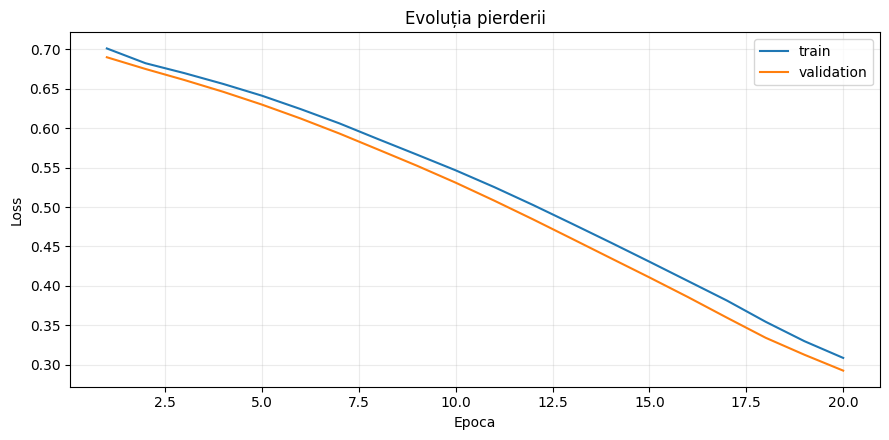

In [6]:
fig = plt.figure(figsize=(9, 4.5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["validation_loss"], label="validation")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.title("Evoluția pierderii")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [7]:
def evaluate_split(indices):
    model.eval()
    with torch.no_grad():
        logits = model(X[indices])
        predictions = logits.argmax(dim=1)
    labels = Y[indices]

    bit_accuracy = float((predictions == labels).float().mean().item())
    prefix_accuracy = float((predictions == labels).all(dim=1).float().mean().item())

    confusion = np.zeros((2, 2), dtype=np.int64)
    flat_pred = predictions.cpu().numpy().ravel()
    flat_true = labels.cpu().numpy().ravel()
    for true_value, pred_value in zip(flat_true, flat_pred):
        confusion[int(true_value), int(pred_value)] += 1

    return bit_accuracy, prefix_accuracy, predictions.cpu().numpy(), confusion

train_metrics = evaluate_split(train_ids)
validation_metrics = evaluate_split(validation_ids)
test_metrics = evaluate_split(test_ids)

metrics_df = pd.DataFrame([
    ["train", train_metrics[0], train_metrics[1], len(train_ids)],
    ["validation", validation_metrics[0], validation_metrics[1], len(validation_ids)],
    ["test", test_metrics[0], test_metrics[1], len(test_ids)],
], columns=["split", "acuratețe_bit", "acuratețe_prefix", "eșantioane"])

display(metrics_df.style.format({
    "acuratețe_bit": "{:.4f}",
    "acuratețe_prefix": "{:.4f}",
}))

,split,acuratețe_bit,acuratețe_prefix,eșantioane
0,train,0.9658,0.6607,112
1,validation,0.9583,0.5417,24
2,test,0.9826,0.7917,24


## Matricea de confuzie și comportamentul pe poziții

Acuratețea totală nu arată dacă anumite poziții din prefix sunt mai greu de estimat. De aceea verificăm și matricea de confuzie, apoi acuratețea pentru fiecare dintre cele 12 poziții.

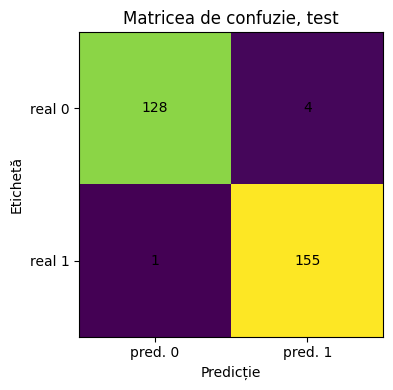

In [8]:
confusion = test_metrics[3]

fig = plt.figure(figsize=(5, 4))
plt.imshow(confusion, interpolation="nearest")
plt.xticks([0, 1], ["pred. 0", "pred. 1"])
plt.yticks([0, 1], ["real 0", "real 1"])
plt.xlabel("Predicție")
plt.ylabel("Etichetă")
plt.title("Matricea de confuzie, test")
for i in range(2):
    for j in range(2):
        plt.text(j, i, int(confusion[i, j]), ha="center", va="center")
plt.tight_layout()
plt.show()

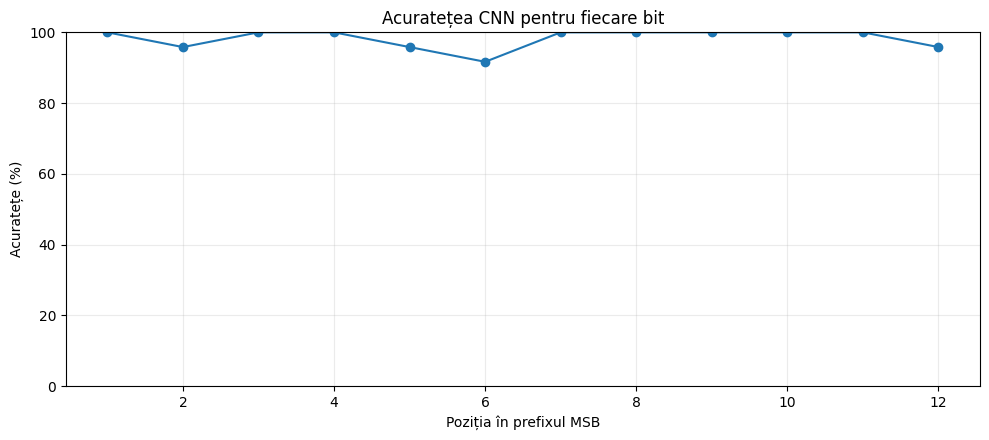

In [9]:
test_predictions = test_metrics[2]
test_labels = Y[test_ids].cpu().numpy()
position_accuracy = (test_predictions == test_labels).mean(axis=0)

fig = plt.figure(figsize=(10, 4.5))
plt.plot(np.arange(1, 13), 100 * position_accuracy, marker="o")
plt.xlabel("Poziția în prefixul MSB")
plt.ylabel("Acuratețe (%)")
plt.title("Acuratețea CNN pentru fiecare bit")
plt.ylim(0, 100)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Ce intră mai departe în HNP

Pentru fiecare semnătură din test, primele 12 predicții formează un prefix întreg:

$$
\bar{k}_i = \sum_{j=0}^{11} \hat{b}_{i,j}\,2^{11-j}.
$$

Prefixul nu este cheia privată și nu este nonce-ul complet. El fixează partea cunoscută din $k_i$ și restrânge intervalul în care se află restul nonce-ului.

In [10]:
def bits_to_int(bits):
    value = 0
    for bit in bits:
        value = (value << 1) | int(bit)
    return value

notebook_predictions = []
for sample_id, predicted_bits in zip(test_ids, test_predictions):
    prefix = bits_to_int(predicted_bits[:12])
    notebook_predictions.append({
        "sample_id": int(sample_id),
        "leaked_bits": 12,
        "predicted_prefix": int(prefix),
    })

cnn_results = {
    "metrics": {
        "train_bit_accuracy": train_metrics[0],
        "train_prefix_accuracy": train_metrics[1],
        "validation_bit_accuracy": validation_metrics[0],
        "validation_prefix_accuracy": validation_metrics[1],
        "test_bit_accuracy": test_metrics[0],
        "test_prefix_accuracy": test_metrics[1],
        "train_samples": len(train_ids),
        "validation_samples": len(validation_ids),
        "test_samples": len(test_ids),
    },
    "hyperparameters": {
        **model_params,
        **training_params,
    },
    "predictions": notebook_predictions,
    "split": {
        "train": train_ids,
        "validation": validation_ids,
        "test": test_ids,
    },
}

model_path = CNN_DIR / "notebook_model_weights.pth"
torch.save(model.state_dict(), model_path)

(ARTIFACTS_DIR / "cnn_notebook_results.json").write_text(
    json.dumps(cnn_results, indent=2),
    encoding="utf-8",
)

print(f"Model salvat: {model_path}")
print("Rezultatele CNN au fost salvate în informatca/artifacts/cnn_notebook_results.json".replace("informatca", "informatica"))

Model salvat: /mnt/data/RoSEF26-27/informatica/cnn/notebook_model_weights.pth
Rezultatele CNN au fost salvate în informatica/artifacts/cnn_notebook_results.json


## Referințe

- PyTorch, [`Conv1d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv1d.html).
- PyTorch, [`CrossEntropyLoss`](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).
- Arhitectura modelului: `informatica/cnn/model.py`.